# Flood → Solar · M1 catalog — **pluvial** (rainfall) depth-at-return-period

**Peril:** Flood · **Layer:** M1 (catalog) · sub-peril **`pluvial`** ([JD-FL-10](../../../../docs/plans/flood/decisions.md) catalog fork)

**Goal:** the **pluvial** depth-at-RP profile — intense-rainfall surface flooding, *"the blind spot"* the FEMA maps
under-map ~3× (Flood-Data-Ref §7). Same output schema as the riverine catalog (so M2/M3 are shared, M4 combines),
`sub_peril="pluvial"`.

**Method = NOAA Atlas 14 rainfall → SCS-CN runoff → DEM-hypsometry ponding ([JD-FL-9](../../../../docs/plans/flood/decisions.md)).**
There is **no free pluvial *depth* product** to anchor to (FFRD pilot-only; First Street/Fathom commercial), so —
unlike riverine (BLE-anchored) — we **model** depth from rainfall with nothing observed to calibrate against. That
makes pluvial inherently **softer**; it's the reference-endorsed free method, flagged honestly.

1. **Frequency** — NOAA Atlas 14 point precipitation-frequency, **24-hr depth** at each RP (the rainfall backbone).
2. **Runoff** — SCS Curve Number (CN≈80, graded solar / soil-C): `Q = (P−0.2S)²/(P+0.8S)`, `S = 1000/CN − 10`.
3. **Ponding** — pour the **retained** runoff `r·Q` over the footprint's 3DEP elevation distribution (≈Normal(μ,σ));
   solve the ponded water surface → `inund_frac`, `conditional_depth`. `r` = on-site **retention** (1 = no-drainage
   upper bound) — the soft knob (drainage), sensitivity-tested in §4 (the pluvial analogue of riverine's onset depth).

In [1]:
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import requests

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"
IN_M = 0.0254   # inch → m

# tiny text cache (Atlas 14 returns CSV, not JSON) — deterministic, flaky-endpoint-robust
import hashlib
_CACHE = OUT / "raw" / "http_cache"; _CACHE.mkdir(parents=True, exist_ok=True)
def cget_text(url, params=None, timeout=40):
    key = hashlib.md5(("T" + url + json.dumps(params, sort_keys=True)).encode()).hexdigest()
    f = _CACHE / (key + ".txt")
    if f.exists():
        return f.read_text()
    t = requests.get(url, params=params, timeout=timeout).text; f.write_text(t); return t

sites = pd.DataFrame(json.loads((OUT / "flood_m0_sites.json").read_text())["sites"])
dem = {s["eia"]: s for s in json.loads((OUT / "flood_m0_dem_context.json").read_text())["sites"]}
print("sites (from M0):")
print(sites[["role", "name", "eia", "state", "lat", "lon"]].to_string(index=False))

sites (from M0):
                role                  name   eia state       lat         lon
baseline (low-flood)  Hayhurst Texas Solar 66880    TX 31.815992 -104.085297
proving (high-flood) Elizabeth Solar Plant 66111    LA 30.819810  -92.971755


## 1 · NOAA Atlas 14 — 24-hr rainfall-at-return-period

Pull the point precipitation-frequency table (partial-duration series, depth, inches) and read the **24-hr** row at
RP = 10/25/50/100/500-yr — the design-storm depths that drive surface ponding.

In [2]:
A14 = "https://hdsc.nws.noaa.gov/cgi-bin/new/fe_text_mean.csv"
RP_COLS = {10: 3, 25: 4, 50: 5, 100: 6, 500: 8}   # header RPs: 1,2,5,10,25,50,100,200,500,1000 (0-indexed after label)
RPS = [10, 25, 50, 100, 500]


def atlas14_24hr(lat, lon):
    txt = cget_text(A14, {"lat": lat, "lon": lon, "type": "pf", "data": "depth", "units": "english", "series": "pds"})
    for line in txt.splitlines():
        if line.lower().startswith("24-hr:"):
            vals = [float(v) for v in line.split(":", 1)[1].replace(" ", "").split(",") if v]
            return {rp: vals[i] for rp, i in RP_COLS.items()}   # inches
    raise ValueError("no 24-hr row in Atlas 14 response")


rain = {}
for _, s in sites.iterrows():
    rain[s["name"]] = atlas14_24hr(s["lat"], s["lon"])
    print(f"  {s['name']:24s} 24-hr rain (in): " + " ".join(f"{rp}yr={rain[s['name']][rp]:.1f}" for rp in RPS))

  Hayhurst Texas Solar     24-hr rain (in): 10yr=3.7 25yr=4.7 50yr=5.5 100yr=6.4 500yr=8.5
  Elizabeth Solar Plant    24-hr rain (in): 10yr=7.8 25yr=9.9 50yr=11.7 100yr=13.8 500yr=19.6


## 2 · Rainfall → runoff (SCS Curve Number) → **sheet** ponding depth

`Q` = net runoff depth (SCS-CN). On a **graded** solar pad, pluvial flooding is **sheet ponding**, not deep
concentration — water sheds down the broad site slope. (We deliberately do **not** pour `Q` into the footprint's
DEM hypsometry: the 10 m DEM's σ≈3.7 m is the site *slope*, not ponding micro-relief, and a volume-conserving
bathtub there gives absurd ~5 ft pools. The DEM is the wrong tool for micro-ponding.) Instead: a fraction `r` of
runoff is **retained** on-site (the rest drains), ponding over the **low-lying fraction** `f` of the pad → the
footprint-average ponding is `r·Q`, the wet-cell (conditional) depth is `r·Q / f`. Both `r` and `f` are documented
soft knobs (no anchor exists — JD-FL-9); `r` is sensitivity-tested in §4.

In [3]:
CN = 80.0          # graded solar open-space, hydrologic soil group C (SCS) — assumption (AFL-P1)
RETENTION = 0.5    # r: fraction of runoff retained on-site (vs drained); 1 = no-drainage upper bound — soft knob
PONDING_FRAC = 0.4  # f: low-lying fraction of the graded pad that ponds (exposure) — soft knob (AFL-P2)


def scs_runoff_in(P_in, cn=CN):
    S = 1000.0 / cn - 10.0
    Ia = 0.2 * S
    return ((P_in - Ia) ** 2 / (P_in + 0.8 * S)) if P_in > Ia else 0.0   # inches


def site_profile(name, eia, retention=RETENTION, frac=PONDING_FRAC, cn=CN):
    rows = []
    for rp in RPS:
        P = rain[name][rp]
        Q_m = scs_runoff_in(P, cn) * IN_M
        avg_pond = retention * Q_m                 # footprint-average retained ponding (m)
        cond = avg_pond / frac if frac > 0 else 0.0  # conditional (wet-cell) depth = retained runoff / ponding area
        rows.append({"rp_years": rp, "rain_in": round(P, 2), "runoff_in": round(scs_runoff_in(P, cn), 2),
                     "inund_frac": round(frac, 3), "depth_wet_m": round(cond, 3),
                     "depth_fp_m": round(avg_pond, 3)})
    return rows


prof = []
for _, s in sites.iterrows():
    for r in site_profile(s["name"], s["eia"]):
        prof.append({"name": s["name"], "role": s["role"], "aep": round(1 / r["rp_years"], 4), **r})
profile = pd.DataFrame(prof)
print(profile[["name", "rp_years", "rain_in", "runoff_in", "inund_frac", "depth_wet_m", "depth_fp_m"]].to_string(index=False))

                 name  rp_years  rain_in  runoff_in  inund_frac  depth_wet_m  depth_fp_m
 Hayhurst Texas Solar        10     3.73       1.82         0.4        0.058       0.023
 Hayhurst Texas Solar        25     4.73       2.66         0.4        0.084       0.034
 Hayhurst Texas Solar        50     5.55       3.38         0.4        0.107       0.043
 Hayhurst Texas Solar       100     6.41       4.15         0.4        0.132       0.053
 Hayhurst Texas Solar       500     8.50       6.10         0.4        0.194       0.077
Elizabeth Solar Plant        10     7.75       5.39         0.4        0.171       0.068
Elizabeth Solar Plant        25     9.87       7.40         0.4        0.235       0.094
Elizabeth Solar Plant        50    11.70       9.16         0.4        0.291       0.116
Elizabeth Solar Plant       100    13.80      11.20         0.4        0.355       0.142
Elizabeth Solar Plant       500    19.60      16.89         0.4        0.536       0.214


## 3 · Plot the pluvial depth-frequency curve

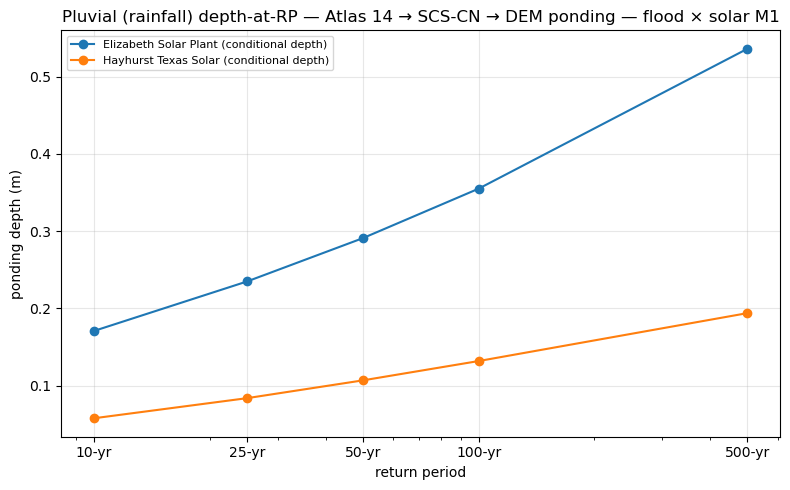

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m1_pluvial_depth_frequency.png


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for nm, g in profile.groupby("name"):
    g = g.sort_values("rp_years")
    ax.plot(g["rp_years"], g["depth_wet_m"], "o-", label=f"{nm} (conditional depth)")
ax.set_xscale("log"); ax.set_xticks(RPS); ax.set_xticklabels([f"{r}-yr" for r in RPS])
ax.set_xlabel("return period"); ax.set_ylabel("ponding depth (m)")
ax.set_title("Pluvial (rainfall) depth-at-RP — Atlas 14 → SCS-CN → DEM ponding — flood × solar M1")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "flood_m1_pluvial_depth_frequency.png", dpi=120, bbox_inches="tight")
plt.show()
print("wrote:", OUT / "flood_m1_pluvial_depth_frequency.png")

## 4 · Sensitivity to the retention knob (the soft, anchorless assumption)

Pluvial has **no depth anchor** (JD-FL-9) — depth scales with `r` (drainage) and `CN`. Here's the proving site's
100-yr conditional depth across plausible `r`. **This spread is the honest pluvial uncertainty** — wide by nature.

In [5]:
prov = sites[sites.role.str.contains("proving")].iloc[0]
print(f"{prov['name']} — 100-yr conditional depth (m) vs retention r:")
for r in (0.25, 0.5, 0.75, 1.0):
    rows = site_profile(prov["name"], prov["eia"], retention=r)
    d100 = [x for x in rows if x["rp_years"] == 100][0]
    print(f"  r={r:.2f}: depth={d100['depth_wet_m']:.2f} m ({d100['depth_wet_m']/0.3048:.1f} ft), inund {d100['inund_frac']*100:.0f}%")
print(f"→ reported with r={RETENTION} (mid). Pluvial depth is assumption-driven (no anchor) — screening-grade.")

Elizabeth Solar Plant — 100-yr conditional depth (m) vs retention r:
  r=0.25: depth=0.18 m (0.6 ft), inund 40%
  r=0.50: depth=0.35 m (1.2 ft), inund 40%
  r=0.75: depth=0.53 m (1.7 ft), inund 40%
  r=1.00: depth=0.71 m (2.3 ft), inund 40%
→ reported with r=0.5 (mid). Pluvial depth is assumption-driven (no anchor) — screening-grade.


## 5 · Known-answer checks (basics-spot-on)

- **Monotone:** rainfall, runoff, and ponding depth all **rise** with return period.
- **Runoff < rainfall** (some infiltrates). **Both sites** get pluvial signal (it rains everywhere — unlike riverine,
  where desert Hayhurst was dry); the *contrast* is weaker than riverine by design.

In [6]:
pv = profile[profile.name == prov["name"]].sort_values("rp_years")
assert pv["depth_wet_m"].is_monotonic_increasing, "pluvial depth must rise with RP"
assert (profile["runoff_in"] <= profile["rain_in"]).all(), "runoff cannot exceed rainfall"
assert (profile["inund_frac"] > 0).all() and (profile["depth_wet_m"] > 0).all(), "pluvial wets every site (rain falls everywhere)"
print(f"✓ {prov['name']}: ponding depth monotone {pv['depth_wet_m'].round(3).tolist()} m")
print("✓ runoff ≤ rainfall everywhere; all sites have pluvial signal (rain is areal)")
print("✓ pluvial known-answer checks pass.")

✓ Elizabeth Solar Plant: ponding depth monotone [0.171, 0.235, 0.291, 0.355, 0.536] m
✓ runoff ≤ rainfall everywhere; all sites have pluvial signal (rain is areal)
✓ pluvial known-answer checks pass.


## 6 · Persist the pluvial catalog manifest (same schema as riverine — JD-FL-10)

In [7]:
manifest = {
    "peril": "flood", "sub_peril": "pluvial", "event_family_id": None, "layer": "M1",
    "depth_source": {
        "method": "NOAA Atlas 14 rainfall → SCS-CN runoff → DEM-hypsometry ponding",
        "frequency": "NOAA Atlas 14 point precip-frequency, 24-hr depth (PFDS CSV)",
        "runoff": f"SCS Curve Number CN={CN} (graded solar / soil-C)",
        "ponding": f"sheet model — avg ponding = r·Q (r={RETENTION} retained), wet-depth = r·Q/f over ponding fraction f={PONDING_FRAC}; DEM hypsometry rejected (10m σ=site slope, not micro-relief → absurd deep pools)",
        "return_periods_yr": RPS, "units": "metres",
        "decision": "JD-FL-9",
    },
    "caveats": [
        "NO depth anchor (vs riverine BLE) — pluvial is the blind-spot; depth is assumption-driven (CN, retention) → screening-grade, wide uncertainty (see §4).",
        "no-drainage retention is an upper bound; CN and the 24-hr duration are assumptions; Atlas 14 LA Vol-9 is stationary/aging — Atlas 15 is the upgrade.",
        "FFRD (pilot) / commercial pluvial grids are the documented swap-ins.",
    ],
    "rainfall_in_24hr": rain,
    "sites": json.loads(profile.to_json(orient="records")),
    "profile": json.loads(profile.to_json(orient="records")),
}
(OUT / "flood_m1_catalog_pluvial_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_m1_catalog_pluvial_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m1_catalog_pluvial_manifest.json


## Findings & what's next

- **Pluvial depth-at-RP catalog built** — Atlas 14 rainfall → SCS-CN runoff → DEM ponding, same schema as riverine
  (`sub_peril="pluvial"`), so **M2/M3 are shared** and **M4 combines** (JD-FL-10).
- **Honest limit:** pluvial is the *blind spot* — **no depth anchor**, so the depth is assumption-driven (retention,
  CN) and **screening-grade** with wide sensitivity (§4). The frequency (Atlas 14) is solid; the depth is soft.
- **Next:** run pluvial through the shared **M2 → M3** (depth→damage), then the **M4 combine** of riverine + pluvial
  (the compound/double-count rule is its own decision).